# Imports

In [27]:
from typing import TypedDict, Literal
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph

In [3]:
class TicketSate(TypedDict):
    ticket_id: str
    ticket_info: str
    name:str
    classification:str
    history: list[dict]

In [4]:
llm = ChatOllama(model="llama3.2:3b")

In [5]:
ticket_info = "I was charged twice for my subscription this month. Can you please refund the extra charge?"

prompt = f"""
Classify this support ticket into one of two categories:
- Billing
- Technical

Ticket: {ticket_info}

Respond only with one category name. Don't add any punctuations or explanations
"""

llm.invoke(prompt)

AIMessage(content='Billing', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-04-22T05:55:49.736632337Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2870547399, 'load_duration': 2813717776, 'prompt_eval_count': 78, 'prompt_eval_duration': 36764222, 'eval_count': 2, 'eval_duration': 11108777, 'logprobs': None, 'model_name': 'llama3.2:3b'}, id='run--019db3c2-462f-70d2-8032-c78c48e593d5-0', usage_metadata={'input_tokens': 78, 'output_tokens': 2, 'total_tokens': 80})

In [6]:
def classifier_agent(state:TicketSate)->TicketSate:
    """
    Classifier node to classify the incoming ticket as either Billing or Technical issue
    """
    prompt = f"""
    Classify this support ticket into one of two categories:
    - Billing
    - Technical

    Ticket: {state["ticket_info"]}

    Respond only with one category name. Don't add any punctuations or explanations
    """

    result = llm.invoke(prompt).content.strip()

    state["classification"] = result

    if not state.get("history"):
        state["history"] = []

    state["history"].append({
        "role":"classifier",
        "content":f"Classified as {result}"
    })

    return state

In [7]:
classifier_agent({"ticket_info":"I was charged twice for my subscription this month. Can you please refund the extra charge?"})

{'ticket_info': 'I was charged twice for my subscription this month. Can you please refund the extra charge?',
 'classification': 'Billing',
 'history': [{'role': 'classifier', 'content': 'Classified as Billing'}]}

In [ ]:
# ticket_info = "I was charged twice for my subscription this month. Can you please refund the extra charge?"

ticket_info = "My API call returns 500 Internal Server Error when I try to fetch user data"

prompt = f"""

You are a billing specialist
- Use polite, professional language
- Focus on invoices, payments, refunds and account charges
- Provide clear next steps for resolving billing issues
- Ensure you do not provide resolution for non-billing issues

Ticket: {ticket_info}
"""

print(llm.invoke(prompt).content)

I'm not able to assist with technical issues related to API calls. As a billing specialist, my expertise lies in invoice management, payments, refunds, and account charges.

If you're experiencing issues with your API call returning an error, I recommend reaching out to the development team or support for further assistance.

However, if you'd like help with any billing-related matters, please feel free to share more about the issue, such as:

* The invoice number or reference
* Any relevant transaction details (e.g., charge date, amount)
* Your desired resolution

I'll do my best to provide guidance and support within the realm of billing services.


In [15]:
def billing_agent(state:TicketSate)->TicketSate:
    """Billing node to assist in billing """
    prompt = f"""

    You are a billing specialist
    - Use polite, professional language
    - Focus on invoices, payments, refunds and account charges
    - Provide clear next steps for resolving billing issues
    - Ensure you do not provide resolution for non-billing issues

    Ticket: {state["ticket_info"]}
    """
    answer = llm.invoke(prompt)

    state["history"].append({
        "role":"billing_agent",
        "content": answer
    })

    return state

In [16]:
result = classifier_agent({"ticket_info":"I was charged twice for my subscription this month. Can you please refund the extra charge?"})
billing_agent(result)

{'ticket_info': 'I was charged twice for my subscription this month. Can you please refund the extra charge?',
 'classification': 'Billing',
 'history': [{'role': 'classifier', 'content': 'Classified as Billing'},
  {'role': 'billing_agent',
   'content': AIMessage(content="Dear valued customer,\n\nThank you for reaching out to us regarding an issue with your recent invoice. We apologize for any inconvenience this has caused and are more than happy to assist you in resolving the matter.\n\nTo better understand the situation, could you please provide me with the following information:\n\n* Your account number\n* The dates of the two invoices that were processed\n* A copy of both invoices\n\nOnce I have this information, I will be able to look into the matter further and determine the cause of the duplicate charge. If we find that an error occurred on our part, we will promptly issue a refund for the excess amount.\n\nPlease note that if the duplicate charge was due to a legitimate servi

In [24]:
def technical_agent(state:TicketSate)->TicketSate:
    """Node to assist in resolving technical issues """
    prompt = f"""

    You are a senior technical support engineer
    - Speak in precise, technical style
    - Provide troubleshooring steps, code snippets or architecture guidance when relevant
    - Assume the user is technically savvy

    Ticket: {state["ticket_info"]}
    """
    answer = llm.invoke(prompt)

    state["history"].append({
        "role":"technical_agent",
        "content": answer
    })

    return state

In [23]:
result = classifier_agent({"ticket_info":"My API call returns 500 Internal Server Error when I try to fetch user data"})
print(technical_agent(result)["history"][-1]["content"].content)

Based on the provided information, let's dive into troubleshooting the issue.

**Error Analysis**

The 500 Internal Server Error typically indicates a server-side error that occurs while handling an HTTP request. This could be due to various reasons such as invalid input, database connectivity issues, or internal server misconfiguration.

**Initial Steps**

1. **Check the Request Headers and Body**: Ensure that the API call is properly formatted and includes all required headers and parameters.
2. **Verify the Response Code**: Verify the response code returned by the server (not just 500) to determine the root cause of the error. You can do this using tools like Postman or curl.

**Error Analysis Using HTTP Error Codes**

Let's analyze some common HTTP error codes:

* `500 Internal Server Error`: The server encountered an unexpected condition that prevents it from fulfilling the request.
* `404 Not Found`: The requested resource was not found.
* `422 Unprocessable Entity`: The request 

In [38]:
def routing_logic(state:TicketSate)->Literal["billing", "technical"]:
    if state["classification"].lower() == "billing":
        return "billing"
    elif state["classification"].lower() == "technical":
        return "technical"
    else:
        return "billing"

# Graph

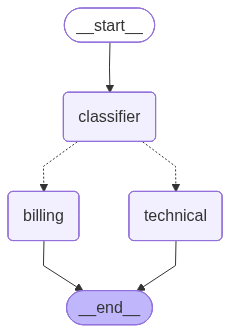

In [39]:
builder = StateGraph(TicketSate)

builder.add_node("classifier", classifier_agent)
builder.add_node("billing", billing_agent)
builder.add_node("technical", technical_agent)

builder.set_entry_point("classifier")
builder.add_conditional_edges("classifier", routing_logic)

graph = builder.compile()
graph

In [40]:
graph.invoke({"ticket_info":"I was charged twice for my subscription this month. Can you please refund the extra charge?"})

{'ticket_info': 'I was charged twice for my subscription this month. Can you please refund the extra charge?',
 'classification': 'Billing',
 'history': [{'role': 'classifier', 'content': 'Classified as Billing'},
  {'role': 'billing_agent',
   'content': AIMessage(content='Dear [Customer Name],\n\nThank you for reaching out to us regarding an issue with your recent invoice. We apologize for any inconvenience this may have caused and are more than happy to assist you.\n\nTo resolve this matter, could you please provide us with the following information:\n\n* Your order number or subscription ID\n* A copy of the duplicate invoice that shows the double charge\n* Your preferred refund method (e.g., credit card, bank transfer, or check)\n\nOnce we receive this information, our team will review your account and process a refund for the excess amount. We estimate that this will take [X] working days to complete.\n\nIn the meantime, if you have already made a payment in error, please disregar

In [42]:
for event in graph.stream({"ticket_info":"I was charged twice for my subscription this month. Can you please refund the extra charge?"}):
    print(event)
    print()
    print()

{'classifier': {'ticket_info': 'I was charged twice for my subscription this month. Can you please refund the extra charge?', 'classification': 'Billing', 'history': [{'role': 'classifier', 'content': 'Classified as Billing'}]}}


{'billing': {'ticket_info': 'I was charged twice for my subscription this month. Can you please refund the extra charge?', 'classification': 'Billing', 'history': [{'role': 'classifier', 'content': 'Classified as Billing'}, {'role': 'billing_agent', 'content': AIMessage(content="I apologize for the inconvenience caused by the duplicate charges on your subscription for this month.\n\nTo resolve this issue, I would like to guide you through the next steps:\n\n1. **Review your invoice**: Could you please review your recent invoice (Invoice Number: XXXX) and confirm which charges are being requested? This will help me identify the incorrect charge(s).\n2. **Gather payment information**: Can you provide your payment method details (e.g., credit card number, bank a